In [1]:
import os
import time
from tqdm import tqdm
import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
from flax.training.train_state import TrainState
from flax.traverse_util import flatten_dict
import safetensors.flax
import optax
import distrax
import assistax
from assistax.wrappers.baselines import get_space_dim, LogEnvState
from assistax.wrappers.baselines import LogWrapper
import hydra
from hydra import compose, initialize
from omegaconf import OmegaConf
from omegaconf import OmegaConf
from typing import Sequence, NamedTuple, Any, Dict
from assistax.baselines.utils import (
    _tree_take, _unstack_tree, _take_episode, _compute_episode_returns,
    _tree_shape, _stack_tree, _concat_tree, _tree_split
    )

ModuleNotFoundError: No module named 'assistax'

In [ ]:
# Create environment 

from ippo_ff_nps import make_train, make_evaluation, EvalInfoLogConfig
from ippo_ff_nps import MultiActorCritic

initialize(version_base=None, config_path="config", job_name="testing_ippo")
cfg = compose(config_name="ippo")
config = OmegaConf.to_container(cfg, resolve=True)

env = assistax.make(config["ENV_NAME"], **config["ENV_KWARGS"])

In [ ]:
# Envrionment API 

print("Env Human Action Size:", env.action_spaces["human"].shape)
print("Env Robot Action Size:", env.action_spaces["robot"].shape)

print("Env Observation Size:", env.observation_spaces["human"].shape)
print("Env Observation Size:", env.observation_spaces["robot"].shape)

In [ ]:
from jax import random

human_action = random.uniform(random.PRNGKey(0), (1, env.action_spaces["human"].shape[0]))
robot_action = random.uniform(random.PRNGKey(1), (1, env.action_spaces["robot"].shape[0]))

env_act = {
    "human": human_action.squeeze(),
    "robot": robot_action.squeeze()
}

In [ ]:
_rng = jax.random.PRNGKey(0)
reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
obsv, env_state = jax.vmap(env.reset)(reset_rng)

In [ ]:
obsv["human"].shape

In [ ]:
_, rng_step = jax.random.split(_rng)

obsv, env_state, reward, done, info = env.step(
    rng_step, env_state, env_act,
)

In [ ]:
env_act

In [ ]:
env_state

# Crossplay

In [16]:
import pandas as pd
index = pd.read_csv('/home/leo/assistive-autonomy-github/assistax/zoo/index.csv')

In [17]:
# First we take just one seed result

import os
import yaml

def flatten_dict(d, parent_key='', sep='_'):
    items = {}
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.update(flatten_dict(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items

# Assume your original DataFrame is named df and has an 'agent_uuid' column.
# For example:
# df = pd.read_csv("your_original_data.csv")

config_folder = '/home/leo/assistive-autonomy-github/assistax/zoo/config'
config_list = []

# Iterate over each agent_uuid in your DataFrame
for agent in index['agent_uuid']:
    config_file = os.path.join(config_folder, f"{agent}.yaml")
    if os.path.exists(config_file):
        with open(config_file, 'r') as f:
            # Load the YAML file
            yaml_data = yaml.safe_load(f)
            # Flatten the YAML data in case it contains nested dictionaries
            flat_data = flatten_dict(yaml_data)
            # Add the agent_uuid to the dictionary (for merging later)
            flat_data['agent_uuid'] = agent
            config_list.append(flat_data)
    else:
        print(f"Warning: Config file for agent {agent} not found.")

# Create a DataFrame from the list of configuration dictionaries
configs_df = pd.DataFrame(config_list)

In [18]:
configs_df.head()

,network_recurrent,network_agent_param_sharing,network_actor_hidden_dim,network_critic_hidden_dim,network_activation,ENV_NAME,ENV_KWARGS_ctrl_cost_weight,ENV_KWARGS_homogenisation_method,ENV_KWARGS_backend,ENV_KWARGS_het_reward,...,ADAM_EPS,GPU_ENV_CAPACITY,ADVANTAGE_UNROLL_DEPTH,DISABLE_JIT,DEVICE,ZOO_PATH,NUM_UPDATES,OBS_DIM,ACT_DIM,agent_uuid
0,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,e954a65e-4f6b-40d7-bbc7-7c7420aa2905
1,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,13cc6c6c-d77b-4296-a63b-a44f2b70df19
2,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,5e7779fa-fb24-4af3-b370-62709868c706
3,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,44256875-5d82-4735-9253-d9cddf08cd2e
4,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,2d5f07f7-e159-4a16-bfe1-3881d21026d6


In [19]:
configs_df.to_csv('/home/leo/assistive-autonomy-github/assistax/zoo/index_configs_df.csv')

In [20]:
configs_df.columns

Index(['network_recurrent', 'network_agent_param_sharing',
       'network_actor_hidden_dim', 'network_critic_hidden_dim',
       'network_activation', 'ENV_NAME', 'ENV_KWARGS_ctrl_cost_weight',
       'ENV_KWARGS_homogenisation_method', 'ENV_KWARGS_backend',
       'ENV_KWARGS_het_reward', 'ENV_KWARGS_disability_joint_idx',
       'ENV_KWARGS_disability_joint_restriction_factor',
       'ENV_KWARGS_disability_joint_strength',
       'ENV_KWARGS_disability_tremor_magnitude',
       'ENV_KWARGS_preference_rewards_preference_weights_speed_preference',
       'ENV_KWARGS_preference_rewards_preference_weights_force_preference',
       'ENV_KWARGS_preference_rewards_preference_weights_action_efficiency',
       'ENV_KWARGS_preference_rewards_preference_weights_touch_penalty',
       'ENV_KWARGS_preference_rewards_preference_ranges_speed_range',
       'ENV_KWARGS_preference_rewards_preference_ranges_force_range',
       'ENV_KWARGS_preference_rewards_preference_ranges_max_action_magnitude',

In [21]:
df = configs_df.copy()

In [22]:
import pandas as pd
import json
import numpy as np

# Assuming your dataframe is called 'df'
# First, identify all ENV_KWARGS columns
env_kwargs_columns = [col for col in df.columns if col.startswith('ENV_KWARGS_')]

print(f"Found {len(env_kwargs_columns)} ENV_KWARGS columns:")
for col in env_kwargs_columns:
    print(f"  - {col}")

# Check which columns have unhashable types
print("\nChecking for unhashable types in ENV_KWARGS columns:")
hashable_columns = []
unhashable_columns = []

for col in env_kwargs_columns:
    try:
        # Try to create a set from the column values
        set(df[col])
        hashable_columns.append(col)
    except TypeError:
        unhashable_columns.append(col)
        print(f"  {col}: contains unhashable types (likely lists/dicts)")

print(f"\nHashable columns: {len(hashable_columns)}")
print(f"Unhashable columns: {len(unhashable_columns)}")

# Method 1: Handle unhashable types by converting to strings
def make_hashable(val):
    """Convert unhashable types to hashable strings"""
    if isinstance(val, (list, dict, np.ndarray)):
        return json.dumps(val, sort_keys=True, default=str)
    elif pd.isna(val):
        return str(val)
    else:
        return val

# Create a copy with hashable versions of ENV_KWARGS columns
df_temp = df.copy()
for col in env_kwargs_columns:
    df_temp[col] = df_temp[col].apply(make_hashable)

# Now drop duplicates
# Now drop duplicates using the temporary dataframe with hashable values
df_deduplicated = df[~df_temp.duplicated(subset=env_kwargs_columns, keep='first')]

print(f"\nOriginal dataframe shape: {df.shape}")
print(f"Deduplicated dataframe shape: {df_deduplicated.shape}")
print(f"Removed {df.shape[0] - df_deduplicated.shape[0]} duplicate rows")


Found 20 ENV_KWARGS columns:
  - ENV_KWARGS_ctrl_cost_weight
  - ENV_KWARGS_homogenisation_method
  - ENV_KWARGS_backend
  - ENV_KWARGS_het_reward
  - ENV_KWARGS_disability_joint_idx
  - ENV_KWARGS_disability_joint_restriction_factor
  - ENV_KWARGS_disability_joint_strength
  - ENV_KWARGS_disability_tremor_magnitude
  - ENV_KWARGS_preference_rewards_preference_weights_speed_preference
  - ENV_KWARGS_preference_rewards_preference_weights_force_preference
  - ENV_KWARGS_preference_rewards_preference_weights_action_efficiency
  - ENV_KWARGS_preference_rewards_preference_weights_touch_penalty
  - ENV_KWARGS_preference_rewards_preference_ranges_speed_range
  - ENV_KWARGS_preference_rewards_preference_ranges_force_range
  - ENV_KWARGS_preference_rewards_preference_ranges_max_action_magnitude
  - ENV_KWARGS_preference_rewards_touch_threshold
  - ENV_KWARGS_preference_rewards_variable_names_speed
  - ENV_KWARGS_preference_rewards_variable_names_force
  - ENV_KWARGS_preference_rewards_variable_

In [23]:
df_deduplicated 

,network_recurrent,network_agent_param_sharing,network_actor_hidden_dim,network_critic_hidden_dim,network_activation,ENV_NAME,ENV_KWARGS_ctrl_cost_weight,ENV_KWARGS_homogenisation_method,ENV_KWARGS_backend,ENV_KWARGS_het_reward,...,ADAM_EPS,GPU_ENV_CAPACITY,ADVANTAGE_UNROLL_DEPTH,DISABLE_JIT,DEVICE,ZOO_PATH,NUM_UPDATES,OBS_DIM,ACT_DIM,agent_uuid
0,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,e954a65e-4f6b-40d7-bbc7-7c7420aa2905
24,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,83d4f7f3-b153-4606-8c5f-03ae934bc300
48,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,5e8b72da-f9ca-4ca5-bac9-7f8d3c491f1f
72,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,4b75efe3-5873-4091-93fa-9f0d6149b5a7
96,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,1819884a-b7fe-48a1-ba58-dc1fadbcc9a6
120,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,9c806b05-f3c6-4712-b061-6b5c90fe6ef3
144,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,076115dd-200f-4484-91ff-6b0df6a1980a
168,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,ea6c876b-44da-4046-b67b-f42b0c82da77
192,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,0098d5ac-cfa4-40a8-a4cf-fc05d54d9704
216,False,False,128,128,relu,scratchitch,0,max,mjx,False,...,1.000000e-08,8192,8,False,0,/home/leo/assistive-autonomy-github/assistax/zoo,57.0,42,7,f5400557-d526-4a78-89e1-0219790e63a4


In [ ]:

# Extract unique agent_uuids from the deduplicated dataframe
selected_agent_uuids = df_deduplicated['agent_uuid'].unique()

print(f"Number of unique agent_uuids in deduplicated data: {len(selected_agent_uuids)}")
print(f"Sample agent_uuids: {selected_agent_uuids[:5]}")  # Show first 5

# Filter the index dataframe to only include rows with matching agent_uuids
selected_index = index[index['agent_uuid'].isin(selected_agent_uuids)]

print(f"\nOriginal index dataframe shape: {index.shape}")
print(f"Selected index dataframe shape: {selected_index.shape}")
print(f"Selected {selected_index.shape[0]} rows from index dataframe")

# Check if all agent_uuids were found
missing_uuids = set(selected_agent_uuids) - set(selected_index['agent_uuid'])
if missing_uuids:
    print(f"\nWarning: {len(missing_uuids)} agent_uuids from deduplicated data were not found in index:")
    print(f"Missing UUIDs: {list(missing_uuids)[:5]}")  # Show first 5 missing
else:
    print("\nAll agent_uuids successfully found in index dataframe!")

# Save to CSV
selected_index.to_csv('/home/leo/assistive-autonomy-github/assistax/zoo/selected_index.csv', index=False)
print(f"\nSaved selected rows to 'selected_index.csv'")

# Optional: Show some statistics about the selection
print(f"\nSelection summary:")
print(f"- Unique agents in deduplicated data: {len(selected_agent_uuids)}")
print(f"- Rows selected from index: {selected_index.shape[0]}")
print(f"- Unique agents in selected index: {selected_index['agent_uuid'].nunique()}")

# If there are duplicate agent_uuids in the index dataframe, you might want to see:
duplicates_in_selected = selected_index['agent_uuid'].duplicated().sum()
if duplicates_in_selected > 0:
    print(f"- Note: {duplicates_in_selected} duplicate agent_uuid entries found in selected data")
    print("  This means some agent_uuids appear multiple times in the index dataframe")

Number of unique agent_uuids in deduplicated data: 12
Sample agent_uuids: ['e954a65e-4f6b-40d7-bbc7-7c7420aa2905'
 '83d4f7f3-b153-4606-8c5f-03ae934bc300'
 '5e8b72da-f9ca-4ca5-bac9-7f8d3c491f1f'
 '4b75efe3-5873-4091-93fa-9f0d6149b5a7'
 '1819884a-b7fe-48a1-ba58-dc1fadbcc9a6']

Original index dataframe shape: (276, 6)
Selected index dataframe shape: (12, 6)
Selected 12 rows from index dataframe

All agent_uuids successfully found in index dataframe!

Saved selected rows to 'selected_index.csv'

Selection summary:
- Unique agents in deduplicated data: 12
- Rows selected from index: 12
- Unique agents in selected index: 12


# Crossplay

In [2]:
import numpy as np

In [4]:
xp_r = np.load('/home/leo/assistive-autonomy-github/assistax/assistax/outputs/crossplay/scratchitch/2025-09-01/12-42-33/crossplay_test_results.npy', allow_pickle=True).item()

In [5]:
xp_r

{'IPPO': {'e954a65e-4f6b-40d7-bbc7-7c7420aa2905': Array([[501.55817, 539.7191 , 520.6861 , 516.4247 , 471.04648, 588.14905,
          451.58813, 498.11505, 501.35724, 388.1502 , 616.2788 , 500.59445]],      dtype=float32),
  '83d4f7f3-b153-4606-8c5f-03ae934bc300': Array([[560.47473, 552.9145 , 570.3441 , 529.37683, 573.137  , 617.208  ,
          483.42676, 561.91174, 553.7981 , 343.02087, 593.29736, 587.23096]],      dtype=float32),
  '5e8b72da-f9ca-4ca5-bac9-7f8d3c491f1f': Array([[402.47052, 600.18994, 579.79236, 441.30713, 682.36566, 522.1252 ,
          471.41403, 488.31073, 668.18164, 324.55917, 479.32455, 563.73987]],      dtype=float32),
  '4b75efe3-5873-4091-93fa-9f0d6149b5a7': Array([[439.13818, 475.8432 , 355.04065, 393.9032 , 539.917  , 454.69043,
          411.42233, 376.119  , 503.75314, 287.63333, 556.6896 , 518.6905 ]],      dtype=float32),
  '1819884a-b7fe-48a1-ba58-dc1fadbcc9a6': Array([[326.45236, 265.10995, 162.4266 , 260.37766, 281.92523, 386.06207,
          464.53

In [6]:
def _tree_shape(pytree):
    return jax.tree.map(lambda x: x.shape, pytree)


print(_tree_shape(xp_r))

{'IPPO': {'0098d5ac-cfa4-40a8-a4cf-fc05d54d9704': (1, 12), '076115dd-200f-4484-91ff-6b0df6a1980a': (1, 12), '1819884a-b7fe-48a1-ba58-dc1fadbcc9a6': (1, 12), '4b75efe3-5873-4091-93fa-9f0d6149b5a7': (1, 12), '5e8b72da-f9ca-4ca5-bac9-7f8d3c491f1f': (1, 12), '83d4f7f3-b153-4606-8c5f-03ae934bc300': (1, 12), '9c806b05-f3c6-4712-b061-6b5c90fe6ef3': (1, 12), '9d3fd87c-3ff7-4616-9be7-ad5aacb8cb82': (1, 12), 'bf5b82eb-0c74-4699-912f-a28894d7563e': (1, 12), 'e954a65e-4f6b-40d7-bbc7-7c7420aa2905': (1, 12), 'ea6c876b-44da-4046-b67b-f42b0c82da77': (1, 12), 'f5400557-d526-4a78-89e1-0219790e63a4': (1, 12)}}


In [15]:
from typing import Dict, Any

def reshape_nested_dict_to_matrix(data: Dict[str, Dict[str, np.ndarray]]) -> tuple[np.ndarray, list[str]]:
    """
    Reshape nested dictionary data into one large matrix combining all algorithms.
    
    Args:
        data: Dictionary with structure {ALGORITHM: {robot_uuid: array[1:n_humans]}}
    
    Returns:
        tuple: (combined_matrix, row_labels) where:
        - combined_matrix: Matrix with all robots from all algorithms
          - Rows: Each robot instance (algorithm_robot_uuid combinations)
          - Columns: human_id (0 to n_humans-1)
        - row_labels: List of strings identifying each row as "algorithm_robot_uuid"
    """
    all_rows = []
    row_labels = []
    
    # Sort algorithms for consistent ordering
    algorithms = sorted(data.keys())
    
    for algorithm in algorithms:
        robot_data = data[algorithm]
        
        # Get all robot UUIDs for this algorithm and sort them
        robot_uuids = sorted(robot_data.keys())
        
        for robot_uuid in robot_uuids:
            robot_array = robot_data[robot_uuid]
            all_rows.append(robot_array)
            row_labels.append(f"{algorithm}_{robot_uuid}")
        
        print(f"Algorithm '{algorithm}': Added {len(robot_uuids)} robots")
    
    # Stack all rows vertically to create the combined matrix
    combined_matrix = np.vstack(all_rows)
    
    print(f"\nCombined matrix shape: {combined_matrix.shape} "
          f"({len(row_labels)} total robots x {combined_matrix.shape[1]} humans)")
    
    return combined_matrix, row_labels

In [17]:
xp_matrix, labels = reshape_nested_dict_to_matrix(xp_r)

Algorithm 'IPPO': Added 12 robots

Combined matrix shape: (12, 12) (12 total robots x 12 humans)


In [18]:
xp_matrix

array([[530.99304, 753.46234, 699.12787, 641.7794 , 759.3515 , 720.81555,
        607.66626, 718.9918 , 620.67053, 429.21765, 626.7771 , 680.7655 ],
       [419.80975, 445.482  , 310.93524, 317.58054, 446.9192 , 458.61142,
        538.61395, 546.2954 , 343.68   , 464.05786, 352.04523, 461.50897],
       [326.45236, 265.10995, 162.4266 , 260.37766, 281.92523, 386.06207,
        464.5368 , 422.0863 , 348.37036, 341.8359 , 288.3029 , 412.82562],
       [439.13818, 475.8432 , 355.04065, 393.9032 , 539.917  , 454.69043,
        411.42233, 376.119  , 503.75314, 287.63333, 556.6896 , 518.6905 ],
       [402.47052, 600.18994, 579.79236, 441.30713, 682.36566, 522.1252 ,
        471.41403, 488.31073, 668.18164, 324.55917, 479.32455, 563.73987],
       [560.47473, 552.9145 , 570.3441 , 529.37683, 573.137  , 617.208  ,
        483.42676, 561.91174, 553.7981 , 343.02087, 593.29736, 587.23096],
       [497.79694, 541.3939 , 505.8236 , 410.6784 , 541.3562 , 556.0405 ,
        459.1433 , 531.45496, 51

In [22]:
xp_matrix.shape

(12, 12)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import squareform
import seaborn as sns

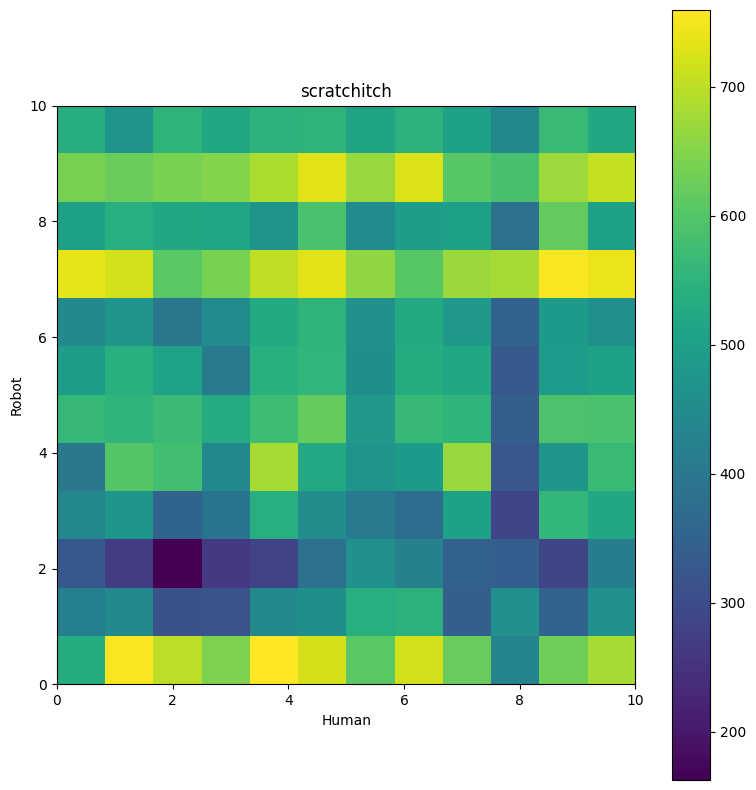

In [32]:
ENV = "scratchitch"  # Define ENV since it's used in the title
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(xp_matrix, aspect='equal', cmap='viridis', extent=[0, 10, 0, 10], origin='lower')
ax.set_xlabel("Human")
ax.set_ylabel("Robot")
ax.set_title(ENV)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [33]:
xp_copy = xp_matrix.copy() / np.max(xp_matrix)

# Make the matrix symmetric by averaging w`ith its transpose
symmetric_matrix = 0.5 * (xp_copy + xp_copy.T)

# Convert similarity to distance matrix for clustering
distance_matrix = 1 - symmetric_matrix

# Perform hierarchical clustering (equivalent to Julia's hclust with ward linkage)
# Convert to condensed form for scipy
condensed_distances = squareform(distance_matrix, checks=False)

# Perform linkage (ward method)
linkage_matrix = linkage(condensed_distances, method='ward')

# Get optimal leaf ordering (equivalent to branchorder=:optimal)
optimal_ordering = optimal_leaf_ordering(linkage_matrix, condensed_distances)

# Cut tree to get clusters (k=12 as in original)
cluster_labels = fcluster(linkage_matrix, t=3, criterion='maxclust')

# Sort by cluster assignments to get permutation
perm = np.argsort(cluster_labels)


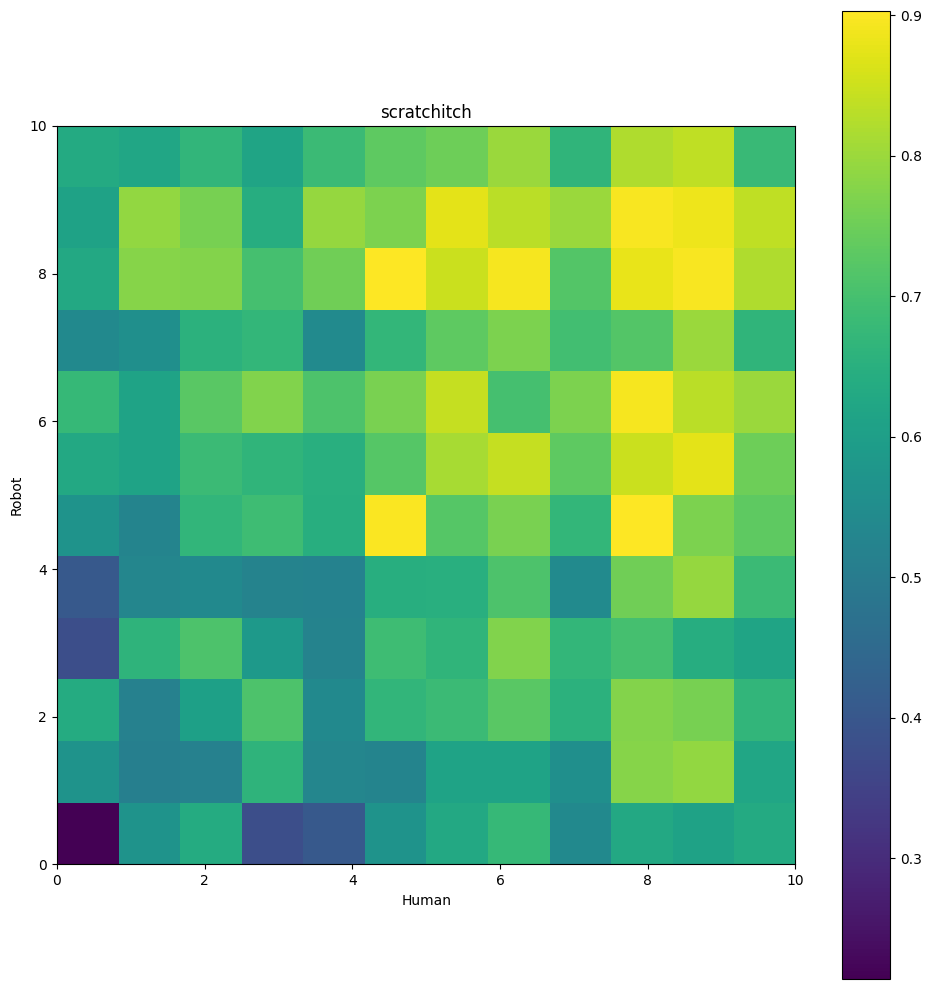

In [34]:
# Create the reordered heatmap
fig_s, ax_s = plt.subplots(figsize=(10, 10))
reordered_matrix = symmetric_matrix[np.ix_(perm, perm)]
im_s = ax_s.imshow(reordered_matrix, aspect='equal', cmap='viridis', extent=[0, 10, 0, 10], origin='lower')
ax_s.set_xlabel("Human")
ax_s.set_ylabel("Robot") 
ax_s.set_title(ENV)
plt.colorbar(im_s)
plt.tight_layout()
plt.show()